# MAST387 Assignment 4

## Tessa Skelly 40265993



## Question 1: Classification using two methods.



P. Cortez, A. Cerdeira, F. Almeida, T. Matos and J. Reis. 
  Modeling wine preferences by data mining from physicochemical properties.
  In Decision Support Systems, Elsevier, 47(4):547-553. ISSN: 0167-9236.

  In the above reference, two datasets were created, using red and white wine samples.
  The inputs include objective tests (e.g. PH values) and the output is based on sensory data
  (median of at least 3 evaluations made by wine experts). Each expert graded the wine quality 
  between 0 (very bad) and 10 (very excellent). Now, you are working in a worldwide Liquor store - VinoVault, as a data scientist. Your boss thinks it is toooo expensive to hire wine experts to rate the wine quality, he/she is willing to pay you more bonus ($ 1 million) to build a crazy model to rate red wines, so that he/she can make a decision of prices and storages. Here, I give you the red wine quality dataset, you are going to build two classfication models to classify these red wines to their quality classes. The feature information is as follows.

  Attribute information:

   For more information, if you are interested, read [Cortez et al., 2009].

   Input variables (based on physicochemical tests):
   
   1. - fixed acidity
   2. - volatile acidity
   3. - citric acid
   4. - residual sugar
   5. - chlorides
   6. - free sulfur dioxide
   7. - total sulfur dioxide
   8. - density
   9. - pH
   10. - sulphates
   11. - alcohol
         
   Output variable (based on sensory data): 
   
   12. - quality (score between 0 and 10)
  
  
  
  
  
  
  Remember:

  1. Your boss do not know math or statistics, he/she won't pay you anything if he/she does not know what you are doing. Visualization is your friend.
  2. I already pre-process your data, but you still need to pre-process it to make it useful.
  3. Make sure to comments your code or code cells, for example, you should comment like: ## Here I work on data pre-processing.
  4. Give model evaluations like confusion matrix and so on.
  5. Make comparsion for your two models.


In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.cluster import KMeans

In [7]:
import warnings

warnings.filterwarnings('ignore')

In [8]:
# download data
wines = pd.read_csv("winequality-red.csv", header=None)

In [9]:
wines.head()

,0,1,2,3,4,5,6,7,8,9,10,11
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


##### Data pre-processing

In [10]:
# rename columns so they make sense
wines = wines.rename(columns = {
    0:"fixed_acidity",
    1:"volatile_acidity",
    2:"citric_acid",
    3:"residual_sugar",
    4:"chlorides",
    5:"free_sulfur_dioxide",
    6:"total_sulfur_dioxide",
    7:"density",
    8:"pH",
    9:"sulphates",
    10:"alcohol",
    11:"quality"})

##### Classification:
I will use the models to classify each red wine as 'good' or not based on its features, this will simplify the decision when considering a wine for the liquor store.

In [11]:
# consider all wines with quality 6 and higher as good (1=good, 0=else)
wines.loc[wines["quality"] >=6, "good"]=1
wines.loc[wines["quality"]<6,"good"]=0

In [12]:
# all data is numeric? check if there are 13 numerical variables
numerical = [var for var in wines.columns if wines[var].dtype!='O']
print('There are {} numerical variables\n'.format(len(numerical)))

There are 13 numerical variables



In [13]:
# check missing values
wines[numerical].isnull().sum()

fixed_acidity           0
volatile_acidity        0
citric_acid             0
residual_sugar          0
chlorides               0
free_sulfur_dioxide     0
total_sulfur_dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
good                    0
dtype: int64

No missing values in any column.

In [14]:
# summary statistics
print(round(wines[numerical].describe(),2))

       fixed_acidity  volatile_acidity  citric_acid  residual_sugar  \
count        1599.00           1599.00      1599.00         1599.00   
mean            8.32              0.53         0.27            2.54   
std             1.74              0.18         0.19            1.41   
min             4.60              0.12         0.00            0.90   
25%             7.10              0.39         0.09            1.90   
50%             7.90              0.52         0.26            2.20   
75%             9.20              0.64         0.42            2.60   
max            15.90              1.58         1.00           15.50   

       chlorides  free_sulfur_dioxide  total_sulfur_dioxide  density       pH  \
count    1599.00              1599.00               1599.00  1599.00  1599.00   
mean        0.09                15.87                 46.47     1.00     3.31   
std         0.05                10.46                 32.90     0.00     0.15   
min         0.01                 1.0

Some of the columns to check on due to possible outliers:
- fixed acidity
- volatile acidity
- residual sugar
- chlorides
- free sulfur dioxide
- total sulfur dioxide
- sulphates


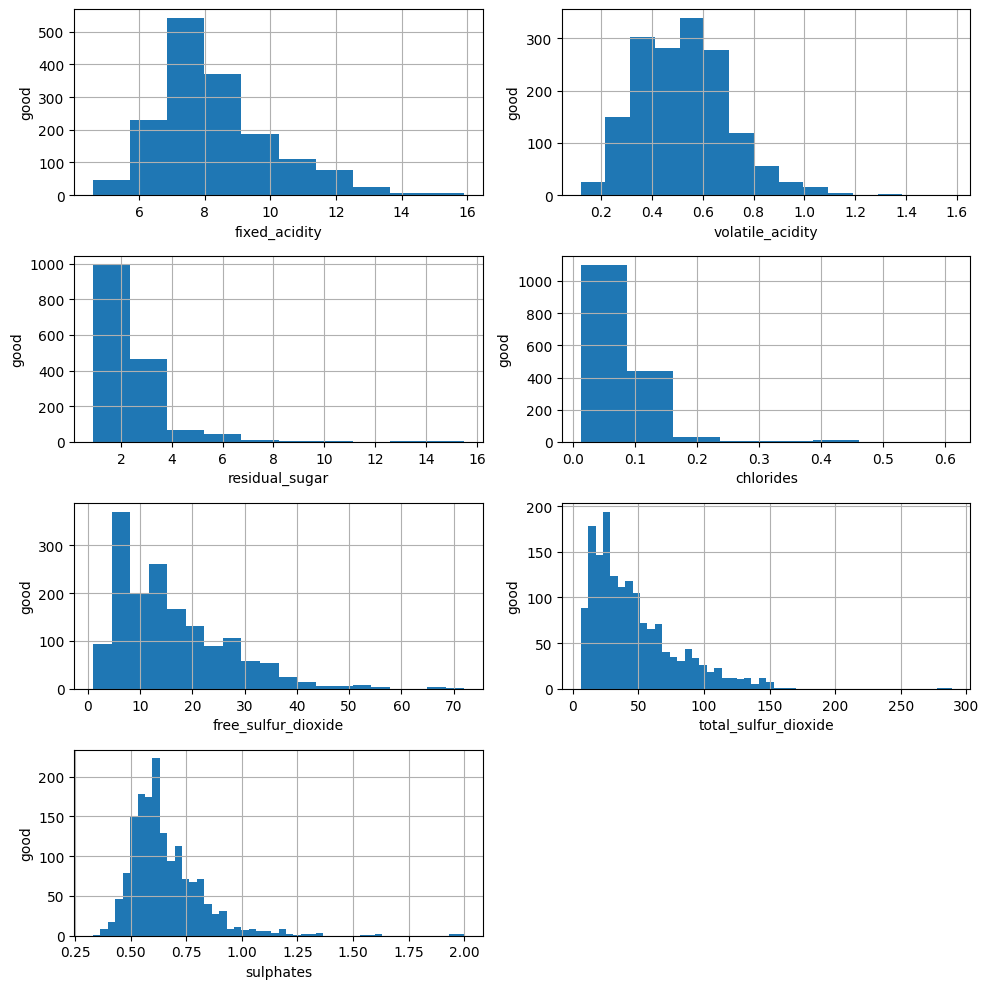

In [16]:
# plot histograms

plt.figure(figsize=(10,10))

#fixed acidity
plt.subplot(4,2,1)
fig=wines.fixed_acidity.hist(bins=10)
fig.set_xlabel('fixed_acidity')
fig.set_ylabel('good')

#volatile acidity
plt.subplot(4,2,2)
fig=wines.volatile_acidity.hist(bins=15)
fig.set_xlabel('volatile_acidity')
fig.set_ylabel('good')

#residual sugar
plt.subplot(4,2,3)
fig=wines.residual_sugar.hist(bins=10)
fig.set_xlabel('residual_sugar')
fig.set_ylabel('good')

#chlorides
plt.subplot(4,2,4)
fig=wines.chlorides.hist(bins=8)
fig.set_xlabel('chlorides')
fig.set_ylabel('good')

# free sulfur dioxide
plt.subplot(4,2,5)
fig=wines.free_sulfur_dioxide.hist(bins=20)
fig.set_xlabel('free_sulfur_dioxide')
fig.set_ylabel('good')

# total sulfur dioxide
plt.subplot(4,2,6)
fig=wines.total_sulfur_dioxide.hist(bins=50)
fig.set_xlabel('total_sulfur_dioxide')
fig.set_ylabel('good')

# sulphates
plt.subplot(4,2,7)
fig=wines.sulphates.hist(bins=50)
fig.set_xlabel('sulphates')
fig.set_ylabel('good')

plt.tight_layout()

From these histograms, the outliers worth noting seem to be the chemicals are skewed to the right due to a few extreme values. 

Check outliers in:
- residual_sugar
- chlorides
- free_sulfur_dioxide
- total_sulfur_dioxide
- sulphates

Some of the wines in the dataset must have very high concentrations of these chemicals.

In [17]:
# outliers for residual sugar
IQR = wines.residual_sugar.quantile(0.75)-wines.residual_sugar.quantile(0.25)
Lower_fence = wines.residual_sugar.quantile(0.25) - (IQR*3)
Upper_fence = wines.residual_sugar.quantile(0.25) + (IQR*3)
print('Residual sugar outliers are values < {lowerboundary} or > {upperboundary}'.format(lowerboundary=Lower_fence, upperboundary=Upper_fence))

Residual sugar outliers are values < -0.20000000000000062 or > 4.0


Since min=0, outliers are values > 4.0

In [18]:
# outliers for chlorides
IQR = wines.chlorides.quantile(0.75)-wines.chlorides.quantile(0.25)
Lower_fence = wines.chlorides.quantile(0.25) - (IQR*3)
Upper_fence = wines.chlorides.quantile(0.25) + (IQR*3)
print('Chloride outliers are values < {lowerboundary} or > {upperboundary}'.format(lowerboundary=Lower_fence, upperboundary=Upper_fence))

Chloride outliers are values < 0.010000000000000037 or > 0.12999999999999998


Min = 0.1 so outliers are values < 0.1 and values > 0.129999999

In [19]:
# outliers for free sulfur dioxide
IQR = wines.free_sulfur_dioxide.quantile(0.75)-wines.free_sulfur_dioxide.quantile(0.25)
Lower_fence = wines.free_sulfur_dioxide.quantile(0.25) - (IQR*3)
Upper_fence = wines.free_sulfur_dioxide.quantile(0.25) + (IQR*3)
print('Free sulfur dioxide outliers are values < {lowerboundary} or > {upperboundary}'.format(lowerboundary=Lower_fence, upperboundary=Upper_fence))

Free sulfur dioxide outliers are values < -35.0 or > 49.0


Since min=0, outliers are values > 49.0

In [20]:
# outliers for total sulfur dioxide
IQR = wines.total_sulfur_dioxide.quantile(0.75)-wines.total_sulfur_dioxide.quantile(0.25)
Lower_fence = wines.total_sulfur_dioxide.quantile(0.25) - (IQR*3)
Upper_fence = wines.total_sulfur_dioxide.quantile(0.25) + (IQR*3)
print('Total sulfur dioxide outliers are values < {lowerboundary} or > {upperboundary}'.format(lowerboundary=Lower_fence, upperboundary=Upper_fence))

Total sulfur dioxide outliers are values < -98.0 or > 142.0


Since min=0, then outliers are values > 142.0

In [21]:
# outliers for sulphates
IQR = wines.sulphates.quantile(0.75)-wines.sulphates.quantile(0.25)
Lower_fence = wines.sulphates.quantile(0.25) - (IQR*3)
Upper_fence = wines.sulphates.quantile(0.25) + (IQR*3)
print('Sulphate outliers are values < {lowerboundary} or > {upperboundary}'.format(lowerboundary=Lower_fence, upperboundary=Upper_fence))

Sulphate outliers are values < 0.010000000000000231 or > 1.0899999999999999


In [22]:
# feature vector and target variable
X = wines.drop(columns=['quality', 'good'])
y =wines['good']

## 1. Logistic Regression Model

I am using logistic regression because it is simple and easy to interpret for binary classification, which helps to determine whether a red wine belongs in the 'good' category or not.

In [23]:
# training and testing sets
X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(X,y,test_size=0.2, random_state=0)

##### Here I will cap the upper outliers so extremely high values do not distort the models.

Will do this for same columns as before
- residual_sugar
- chlorides
- free_sulfur_dioxide
- total_sulfur_dioxide
- sulphates

In [24]:
# if value is higher than top, then it takes on value of top, otherwise it stays the same
def max_value(df, variable, top):
    return np.where(df[variable]>top, top, df[variable])
    
# using the upper fence as top
for wines in [X_train_lr, X_test_lr]:
    wines['residual_sugar'] = max_value(wines, 'residual_sugar', 4.0)
    wines['chlorides'] = max_value(wines, 'chlorides', 0.13)
    wines['free_sulfur_dioxide'] = max_value(wines, 'free_sulfur_dioxide', 49.0)
    wines['total_sulfur_dioxide'] = max_value(wines, 'total_sulfur_dioxide', 142.0)
    wines['sulphates'] = max_value(wines, 'sulphates',1.09)

In [25]:
X_train_lr.describe()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol
count,1279.000000,1279.000000,1279.000000,1279.000000,1279.000000,1279.000000,1279.000000,1279.000000,1279.000000,1279.000000,1279.000000
mean,8.337373,0.530000,0.272181,2.356880,0.081293,15.939015,46.802189,0.996757,3.309828,0.652541,10.413995
std,1.734938,0.182544,0.195608,0.685876,0.019134,10.155086,32.191797,0.001882,0.153968,0.145893,1.061308
min,4.700000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.370000,8.400000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,8.000000,22.000000,0.995620,3.210000,0.550000,9.500000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996760,3.310000,0.620000,10.200000
75%,9.300000,0.637500,0.420000,2.600000,0.090000,21.000000,63.000000,0.997855,3.400000,0.730000,11.083333
max,15.900000,1.580000,1.000000,4.000000,0.130000,49.000000,142.000000,1.003690,4.010000,1.090000,14.900000


The maximum values of these wine attributes are now the capped values.

##### Mapping all variables to the same scale so it is ready for model building.

In [26]:
cols = X_train_lr.columns

scaler = MinMaxScaler()

X_train_lr = scaler.fit_transform(X_train_lr)
X_test_lr = scaler.transform(X_test_lr)

In [27]:
X_train_lr = pd.DataFrame(X_train_lr, columns=[cols])
X_test_lr = pd.DataFrame(X_test_lr, columns=[cols])
X_train_lr.describe()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol
count,1279.000000,1279.000000,1279.000000,1279.000000,1279.000000,1279.000000,1279.000000,1279.000000,1279.000000,1279.000000,1279.000000
mean,0.324765,0.280822,0.272181,0.469961,0.587230,0.311229,0.300016,0.491003,0.448683,0.392418,0.309845
std,0.154905,0.125030,0.195608,0.221250,0.162151,0.211564,0.236704,0.138212,0.121234,0.202630,0.163278
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.214286,0.184932,0.090000,0.322581,0.491525,0.145833,0.117647,0.407489,0.370079,0.250000,0.169231
50%,0.285714,0.273973,0.260000,0.419355,0.567797,0.270833,0.235294,0.491189,0.448819,0.347222,0.276923
75%,0.410714,0.354452,0.420000,0.548387,0.661017,0.416667,0.419118,0.571586,0.519685,0.500000,0.412821
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


All of the data matches the same scale now with min=0 and max=1.00.

#### Now I will train a logistic regression model on the training set

In [28]:
logreg = LogisticRegression(solver='liblinear', random_state=0)

# fit model
logreg.fit(X_train_lr, y_train_lr)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,0
,solver,'liblinear'
,max_iter,100
,multi_class,'deprecated'


##### Now I will use my trained and fitted model to predict results

In [29]:
y_pred_test_lr = logreg.predict(X_test_lr)
y_pred_test_lr

array([1., 0., 1., 0., 1., 0., 0., 1., 0., 0., 0., 0., 1., 0., 1., 1., 1.,
       1., 1., 0., 1., 0., 1., 1., 0., 0., 0., 1., 0., 1., 1., 1., 1., 0.,
       1., 1., 0., 1., 1., 1., 0., 1., 1., 1., 1., 0., 0., 1., 0., 1., 0.,
       0., 1., 1., 1., 0., 0., 0., 1., 0., 0., 1., 1., 1., 0., 1., 0., 1.,
       1., 1., 0., 1., 0., 0., 1., 1., 0., 0., 0., 1., 1., 0., 1., 1., 1.,
       0., 1., 0., 0., 0., 0., 0., 1., 0., 1., 0., 1., 0., 0., 1., 1., 1.,
       1., 1., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 1., 1., 1., 1.,
       1., 0., 1., 1., 0., 1., 1., 0., 0., 1., 1., 0., 0., 1., 1., 1., 0.,
       1., 0., 1., 0., 1., 0., 0., 0., 1., 1., 1., 1., 1., 0., 1., 1., 0.,
       1., 1., 0., 0., 0., 1., 1., 1., 1., 1., 0., 1., 0., 1., 1., 0., 1.,
       1., 1., 0., 1., 1., 1., 1., 1., 1., 0., 0., 1., 0., 1., 1., 0., 1.,
       1., 0., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0.,
       0., 0., 0., 1., 1., 0., 1., 1., 1., 1., 0., 1., 1., 1., 1., 0., 0.,
       1., 1., 1., 0., 1.

1 = good wine, 0 = not good

Get probabilities of getting 1 or 0:

In [30]:
# probability of getting 0 (not good wine) or 1 (good wine)
proba = logreg.predict_proba(X_test_lr)

# dataframe for probability visualization
prob_results = pd.DataFrame({
    'prob_not_good': proba[:,0],
    'prob_good': proba[:,1],
    'prediction':logreg.predict(X_test_lr)
})

prob_results.head(10)

,prob_not_good,prob_good,prediction
0,0.371630,0.628370,1.0
1,0.743531,0.256469,0.0
2,0.063392,0.936608,1.0
3,0.601734,0.398266,0.0
4,0.263234,0.736766,1.0
5,0.849501,0.150499,0.0
6,0.557884,0.442116,0.0
7,0.202899,0.797101,1.0
8,0.806865,0.193135,0.0
9,0.841603,0.158397,0.0


This data table shows the probability from 0 to 1.0 of a wine being classified as good or not good, as well as the prediction of where it will be classified with 1 = good wine, and 0 = not good wine.

By comparing the test classification results with the actual results,

##### Here is my model accuracy score:

In [31]:
print('Model accuracy: {0:0.4f}'.format(accuracy_score(y_test_lr, y_pred_test_lr)))

Model accuracy: 0.7500


In [32]:
# Compare train-set and test-set to check for overfitting and get accuracy score
y_pred_train_lr = logreg.predict(X_train_lr)

print('Training-set accuracy score: {0:0.4f}'.format(accuracy_score(y_train_lr, y_pred_train_lr)))

Training-set accuracy score: 0.7389


#### Evaluation for the model:


I will compare my model with the null accuracy. This will compare my model to a simple one that computes the most frequent class accuracy by number of occurences.

In [33]:
y_test_lr.value_counts()

good
1.0    172
0.0    148
Name: count, dtype: int64

In [34]:
null_accuracy = 172/(172+148)

print('Null accuracy: {0:0.4f}'.format(null_accuracy))

Null accuracy: 0.5375


This shows that my model for classifying wine is much better at predicting if it is good or not than by just using the null accuracy.

To evaluate, I will also create a confusion matrix which will separate the data to identify the errors and wrong predictions from the model.

In [35]:
# print confusion matrix
cm = confusion_matrix(y_test_lr, y_pred_test_lr)
print('Confusion matrix\n\n',cm)
print('\nTrue Positives =',cm[0,0])
print('\nTrue Negatives =',cm[1,1])
print('\nFalse Positives =',cm[0,1])
print('\nFalse Negatives =',cm[1,0])

Confusion matrix

 [[106  42]
 [ 38 134]]

True Positives = 106

True Negatives = 134

False Positives = 42

False Negatives = 38


In total there are 240 correct predictions and 80 incorrect ones. 

Correctly predicted 
- 1: 134
- 0: 106

Incorrectly predicted 
- 1: 42
- 0: 38


This shows that the model makes mostly correct predictions, to show this more clearly, here is a heatmap to show the impact of each section of the confusion matrix.

<Axes: >

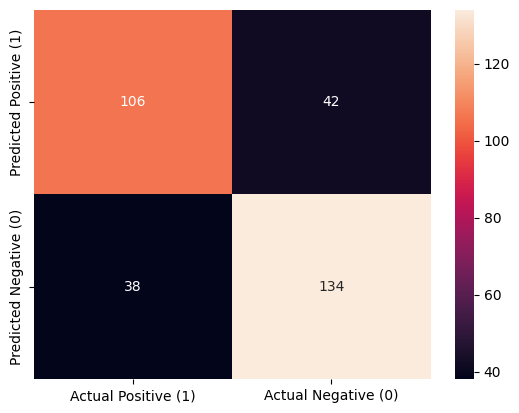

In [38]:
# seaborn heatmap 
cm_matrix = pd.DataFrame(data=cm, columns=['Actual Positive (1)', 'Actual Negative (0)'], 
                         index=['Predicted Positive (1)', 'Predicted Negative (0)']) 

sns.heatmap(cm_matrix, annot=True, fmt='d')

## 2. Random Forest Model

Next, I will use the Random Forest model to generate better predictions. This is an ensemble of decision trees, which are less powerful prediction models but easy to use, as it consistently splits the data into binary categories until the input is classified.

I am using this model since it can handle datasets with many features, such as the red wine data set and all of its chemical attributes.

I will use this model with 100 decision-trees.

In [39]:
# split into train and test sets
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(X, y, test_size = 0.2, random_state = 0)

In [40]:
# check shapes of training and testing sets
X_train_rf.shape, X_test_rf.shape

((1279, 11), (320, 11))

In [41]:
# use random forest classifier
rfc = RandomForestClassifier(n_estimators=100,random_state=0)

# fit model
rfc.fit(X_train_rf, y_train_rf)

# predict test set results
y_pred_rf = rfc.predict(X_test_rf)


##### Accuracy of the model:

Checked using the actual y values with the predicted ones from the test set.

In [42]:
print('Model accuracy score with 100 decision-trees: {0: 0.4f}'.format(accuracy_score(y_test_rf, y_pred_rf)))

Model accuracy score with 100 decision-trees:  0.8250


##### Adding more trees:

I want to try with 200 trees to see if I get better predictions.

In [43]:
rfc200 = RandomForestClassifier(n_estimators=200, random_state=0)

# fit
rfc200.fit(X_train_rf, y_train_rf)

# predict
y_pred_rf_200 = rfc200.predict(X_test_rf)

In [44]:
# check accuracy
print('Model accuracy score with 200 decision-trees: {0: 0.4f}'.format(accuracy_score(y_test_rf, y_pred_rf_200)))

Model accuracy score with 200 decision-trees:  0.8219


The model did not become more accurate so I would stick with 100 decision-trees.

##### Important features:

I will check the important features of the dataset to see if any are worth removing so the accuracy of the model can improve.

In [45]:
# get important features
imp_feats = pd.Series(rfc.feature_importances_, index=X_train_rf.columns).sort_values(ascending=False)
imp_feats_sorted = imp_feats.sort_values()
imp_feats

alcohol                 0.185959
sulphates               0.135849
volatile_acidity        0.107083
total_sulfur_dioxide    0.099468
density                 0.088339
chlorides               0.071721
pH                      0.067698
fixed_acidity           0.065905
citric_acid             0.062831
free_sulfur_dioxide     0.060665
residual_sugar          0.054482
dtype: float64

As shown above, the most important feature is alcohol, and the least important is residual sugar.

I will show this in a horizontal bar plot.

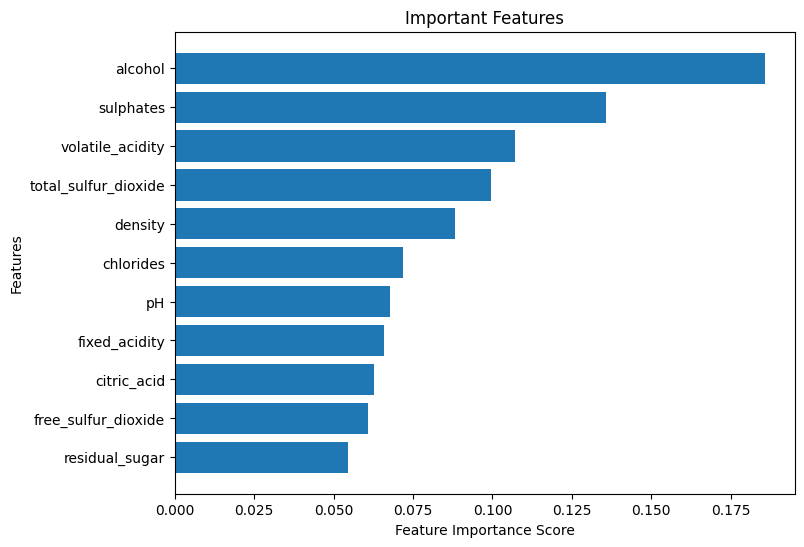

In [46]:
plt.figure(figsize=(8,6))
plt.barh(imp_feats_sorted.index, imp_feats_sorted.values)
plt.xlabel('Feature Importance Score')
plt.ylabel('Features')
plt.title('Important Features')
plt.show()

Even though the least important feature is residual_sugar, it still seems to have too much of an impact to remove it from the model, therefore I will keep all features in the Random Model with 100 decision-trees.

#### Evaluation of the model:

To evaluate the model I will use another confusion matrix as well as a classification report.

##### Confusion matrix

In [47]:
cm_rf = confusion_matrix(y_test_rf, y_pred_rf)
print('Confusion matrix\n\n',cm_rf)

print('\nTrue Positives =',cm_rf[0,0])
print('\nTrue Negatives =',cm_rf[1,1])
print('\nFalse Positives =',cm_rf[0,1])
print('\nFalse Negatives =',cm_rf[1,0])


Confusion matrix

 [[122  26]
 [ 30 142]]

True Positives = 122

True Negatives = 142

False Positives = 26

False Negatives = 30


Again, to show the impact of errors with this model, I will use a heatmap:

<Axes: >

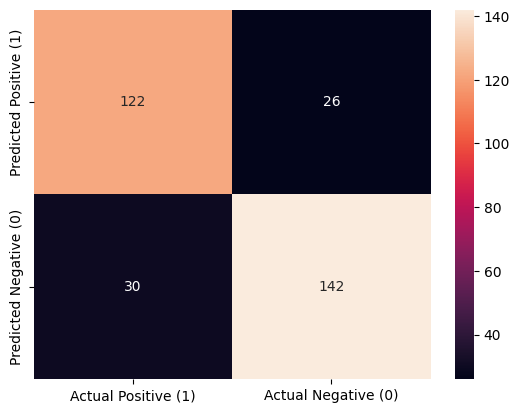

In [48]:
# seaborn heatmap 
cm_matrix_rf = pd.DataFrame(data=cm_rf, columns=['Actual Positive (1)', 'Actual Negative (0)'], 
                         index=['Predicted Positive (1)', 'Predicted Negative (0)']) 

sns.heatmap(cm_matrix_rf, annot=True, fmt='d')

##### Classification report

This will show the precision, recall, f1 and support scores of the model.

Precision is how many of the predictions were actually correct.

Recall is for how many of all of the true instances were correctly reported.

F1 is the score that explains how good the model is at recall and precision.

Support is how many instances are being calculated for the classes.

In [49]:
print(classification_report(y_test_rf, y_pred_rf))

              precision    recall  f1-score   support

         0.0       0.80      0.82      0.81       148
         1.0       0.85      0.83      0.84       172

    accuracy                           0.82       320
   macro avg       0.82      0.82      0.82       320
weighted avg       0.83      0.82      0.83       320



This classification report shows that out of all the y-values, if it predicted a wine was not good, it was correct 80% of the time, for good wine, it was correct 85% of the time.

It also shows that out of all the good wines, the model got 83% of them right, and for all 'not good' wines, the model got 82% of them.

### Comparison between Logistic Regression and Random Forest models:

The classification matrix for each model clearly shows a significant difference in the accuracy from Logistic Regression to the Random Forest model, which goes from 75% accuracy to 82.5% accuracy. Since it is a more precise predictive model, I would choose the Random Forest Model for classifying a red wine as 'good' or not based on its attributes.

## Question 2: Clustering using k-means

Ok, you are doing great! You almost win that bonus. Your boss thinks the wine quality column in your dataset is not realiable, since it is based on some experts. He wants to know if there is a way to cluster these wines based on some similarities. Here you can try to use the k-means to cluster your data (remember to not use the quality column to fit your k-means model and use this column as a test).

In [50]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [51]:
# load data and rename columns
wines = pd.read_csv('winequality-red.csv', header=None)
wines = wines.rename(columns = {
    0:"fixed_acidity",
    1:"volatile_acidity",
    2:"citric_acid",
    3:"residual_sugar",
    4:"chlorides",
    5:"free_sulfur_dioxide",
    6:"total_sulfur_dioxide",
    7:"density",
    8:"pH",
    9:"sulphates",
    10:"alcohol",
    11:"quality"})

In [52]:
# drop quality column
X = wines.drop(columns=['quality'])
y = wines['quality']

#scale features
scale = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [55]:
# fit k-means on training data
kmeans = KMeans(n_clusters=3, random_state=0)
kmeans.fit(X_scaled)


# predict
labels = kmeans.predict(X_scaled)

# "good" wine variable
wines["good"] = (wines["quality"] >= 6).astype(int)

# clusters
cluster_df = pd.DataFrame({"cluster" : labels,
                           "good" : wines["good"]})

# crosstab
ct = pd.crosstab(cluster_df["cluster"], cluster_df["good"])
print(ct)

# use dimension reduction for plot since there are 11 variables
pca = PCA(n_components=2)
pca.fit(X_scaled)
X_pca=pca.transform(X_scaled)

good       0    1
cluster          
0         55  280
1        172  299
2        517  276


The cluster crosstab shows that cluster 0 contains mostly "good" wines, cluster 1 contains a mix but slightly more "good", while cluster 2 contains more "not-good" wines.

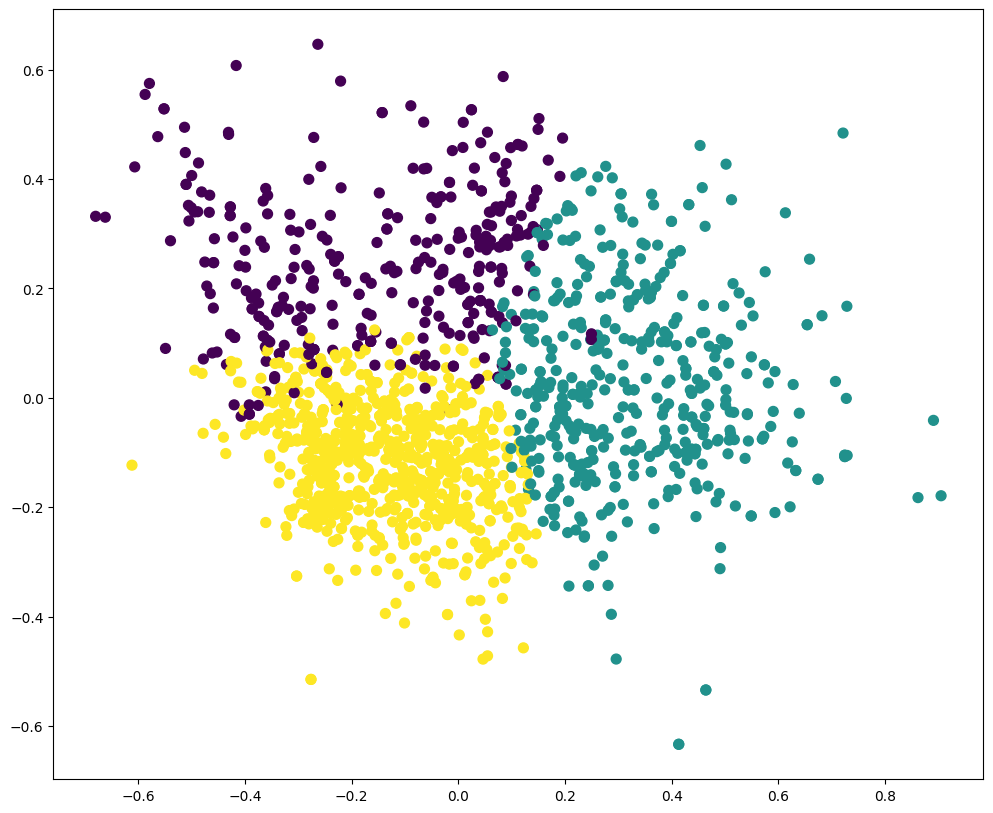

In [56]:
# scatter plot of clusters
plt.figure(figsize=(12,10))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels, s=50, cmap='viridis')

The red wine data can be clustered in 3 different blobs based on similarities.

I initially had tried with 4 clusters but the data was not properly separated, so 3 clusters gave a more significant grouping.

##### Conclusion
To evaluate whether clustering is useful, I compared the clusters with the actual "good" wine labels. The results show that some clusters contain a higher proportion of good wines, but the separation is not perfect, as some overlap exists between "good" and "not-good" wines in the same clusters. This suggests that while clustering can capture some structure in the data, it may not be reliable enough as the only tool to determine wine quality. However, it could still be useful for exploration or to group similar wines for further analysis.

Bravo! You are the winner!